# Phase 1 — Pair selection & cointegration

**Goal:** decide which candidate pairs have a statistical case for mean reversion, before any trading logic exists.

Pipeline: correlation pre-screen → Engle-Granger step 1 (OLS hedge ratio) → step 2 (ADF on the residual) → pairs that pass go to Phase 2.

> **Data caveat:** yfinance 5-minute bars give only ~60 calendar days (~40 trading days). Treat every p-value here as coming from a *short* sample. See README → *Data limitations*.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))   # make /src importable

import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
%matplotlib inline

## 1. Load and align data
Bars are cleaned to the NSE session (09:15–15:30 IST) and inner-joined on timestamp. We do **not** forward-fill missing bars, because a stale price on one leg creates a fake spread move.

In [2]:
from data_pipeline import load_universe, split_formation_trading
from cointegration import FORMATION_DAYS

universe = load_universe()
summary = pd.DataFrame({k: {"bars": len(v), "days": v.index.normalize().nunique(),
                            "start": v.index[0], "end": v.index[-1]} for k, v in universe.items()}).T
summary

,bars,days,start,end
HDFCBANK/ICICIBANK,4331,59,2026-07-09 09:15:00+05:30,2026-09-30 15:10:00+05:30
TCS/INFY,4325,59,2026-07-09 09:15:00+05:30,2026-09-30 15:15:00+05:30
SBIN/BANKBARODA,4325,59,2026-07-09 09:15:00+05:30,2026-09-30 15:15:00+05:30


## 2. Formation vs trading split
Pair selection uses **only the first `FORMATION_DAYS` trading days**. If we tested cointegration on the full sample and then backtested on the same data, the backtest would already "know" which pairs were going to mean-revert (selection lookahead bias).

In [3]:
formation, trading = {}, {}
for k, v in universe.items():
    formation[k], trading[k] = split_formation_trading(v, FORMATION_DAYS)
print(f"FORMATION_DAYS = {FORMATION_DAYS}")
pd.DataFrame({k: {"formation bars": len(formation[k]), "trading bars": len(trading[k])} for k in universe}).T

FORMATION_DAYS = 15


,formation bars,trading bars
HDFCBANK/ICICIBANK,1125,3206
TCS/INFY,1125,3200
SBIN/BANKBARODA,1125,3200


## 3. Correlation pre-screen
Rolling correlation of **prices** over ~5 days. This is a cheap filter only: two trending series can be highly correlated without being cointegrated (spurious regression), so passing it proves nothing. Failing it is still a useful warning.

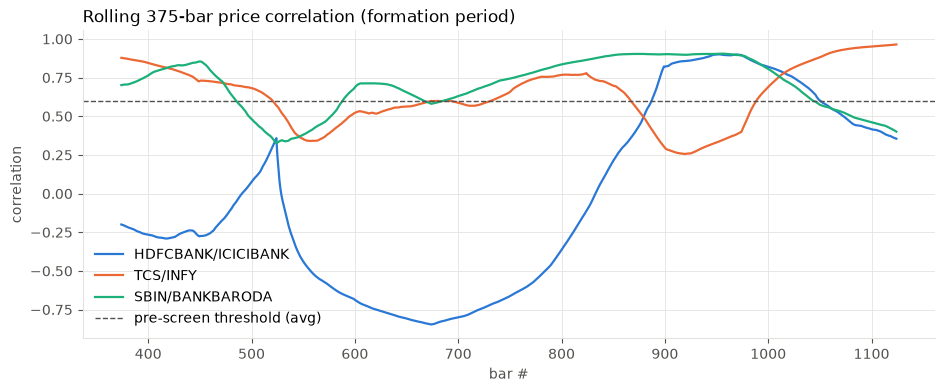

In [4]:
from cointegration import rolling_correlation, CORR_WINDOW, MIN_AVG_CORRELATION
from backtest_report import SERIES_COLORS

fig, ax = plt.subplots()
for i, (k, v) in enumerate(formation.items()):
    rc = rolling_correlation(v.iloc[:, 0], v.iloc[:, 1], CORR_WINDOW)
    ax.plot(range(len(rc)), rc.values, color=SERIES_COLORS[i], label=k)
ax.axhline(MIN_AVG_CORRELATION, color="#52514e", ls="--", lw=1, label="pre-screen threshold (avg)")
ax.set_title(f"Rolling {CORR_WINDOW}-bar price correlation (formation period)", loc="left")
ax.set_xlabel("bar #"); ax.set_ylabel("correlation"); ax.legend(loc="lower left")
plt.show()

## 4. Engle-Granger two-step test

**Step 1:** OLS `price_A = alpha + beta * price_B + residual`. beta is the hedge ratio.

**Step 2:** ADF on the residual.
- **H0:** residual has a unit root → non-stationary → **not** cointegrated.
- **H1:** residual is stationary → cointegrated (the spread mean-reverts).
- p < 0.05 → reject H0. A failure to reject is *not* proof of a unit root, only insufficient evidence of mean reversion.

**Two p-values are reported:**
- `adf_p_value`: plain `adfuller` on the residual (the same interpretation as the earlier returns work).
- `eg_p_value`: the same statistic judged against **Engle-Granger (MacKinnon) critical values** (`statsmodels.coint`). OLS picks beta to make the residual look as stationary as possible, so the plain ADF critical values are too lenient. The decision uses `eg_p_value` (`USE_ENGLE_GRANGER_PVALUE = True`).

In [5]:
from cointegration import screen_pairs, summary_table, select_pairs_for_trading

phase1 = screen_pairs(formation)
summary_table(phase1)

,hedge_ratio,adf_stat,adf_p_value,eg_p_value,cointegrated,avg_rolling_corr,half_life_bars,proceed
pair,,,,,,,,
HDFCBANK/ICICIBANK,-1.0349,-1.4637,0.5514,0.7743,N,-0.0287,133.4805,False
TCS/INFY,2.0785,-1.4748,0.5459,0.7736,N,0.6383,328.2891,False
SBIN/BANKBARODA,3.0296,-2.9976,0.0351,0.1105,N,0.7009,45.9783,False


**Reading the table**
- `hedge_ratio`: shares of B per share of A in the formation-period OLS.
- `adf_stat` vs the 5% critical value (~-2.86 for plain ADF, ~-3.34 for a two-variable Engle-Granger test). More negative means stronger evidence of stationarity.
- `half_life_bars`: AR(1)-implied time for a deviation to halve. If it is far longer than the 60-bar z-score window, the spread does not revert on our trading horizon.
- A pair where `adf_p_value < 0.05` but `eg_p_value > 0.05` is the textbook trap: the naive test says "cointegrated", the correct one says "not proven".

In [6]:
# Same test on the full sample, for reference only (NOT used for selection: it would be lookahead)
summary_table(screen_pairs(universe))[["hedge_ratio", "adf_stat", "adf_p_value", "eg_p_value", "cointegrated"]]

,hedge_ratio,adf_stat,adf_p_value,eg_p_value,cointegrated
pair,,,,,
HDFCBANK/ICICIBANK,0.1480,-2.4314,0.1331,0.3476,N
TCS/INFY,1.9100,-3.0103,0.0339,0.1087,N
SBIN/BANKBARODA,4.2573,-2.2242,0.1976,0.4117,N


## 5. Visualise the formation-period spread
Residual from step 1 with ±2 std bands. A cointegrated spread should cross its mean often. A non-cointegrated one wanders.

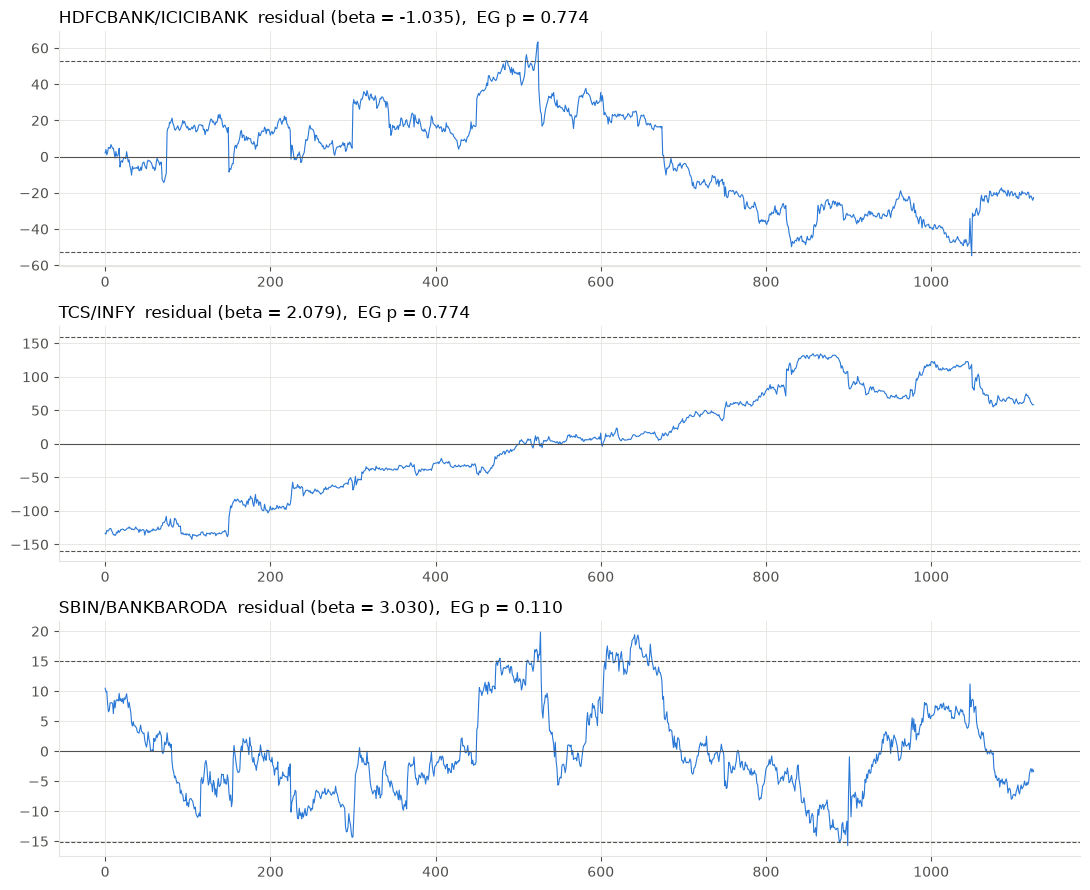

In [7]:
from cointegration import estimate_hedge_ratio

fig, axes = plt.subplots(len(formation), 1, figsize=(11, 3 * len(formation)))
for ax, (k, v) in zip(axes, formation.items()):
    _, beta, resid = estimate_hedge_ratio(v.iloc[:, 0], v.iloc[:, 1])
    ax.plot(range(len(resid)), resid.values, color=SERIES_COLORS[0], lw=0.8)
    for m in (-2, 0, 2):
        ax.axhline(m * resid.std(), color="#52514e", lw=0.8, ls="--" if m else "-")
    ax.set_title(f"{k}  residual (beta = {beta:.3f}),  EG p = {phase1.loc[k, 'eg_p_value']:.3f}", loc="left")
fig.tight_layout(); plt.show()

## 6. Which pairs proceed?
Only pairs passing **both** the pre-screen and the cointegration test proceed. If none pass, `ALLOW_FALLBACK_TO_BEST_PAIR` lets Phases 2–4 run on the lowest-p-value pair **for pipeline demonstration only**. In that case every later result should be read as *"what happens when you trade a pair without statistical support"*, not as evidence of an edge.

In [8]:
selected, used_fallback = select_pairs_for_trading(phase1)
print("Proceeding to Phase 2:", selected, "| fallback:", used_fallback)

Proceeding to Phase 2: ['SBIN/BANKBARODA'] | fallback: True
